In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from  sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score


df = pd.read_csv("exams.csv")



EDA

In [10]:
df.head() #

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,some college,standard,completed,59,70,78
1,male,group D,associate's degree,standard,none,96,93,87
2,female,group D,some college,free/reduced,none,57,76,77
3,male,group B,some college,free/reduced,none,70,70,63
4,female,group D,associate's degree,standard,none,83,85,86


In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [13]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [15]:
print(df.duplicated().sum())

0


In [16]:
print(df.isna().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [17]:
df.describe()

,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,67.810000,70.382000,69.140000
std,15.250196,14.107413,15.025917
min,15.000000,25.000000,15.000000
25%,58.000000,61.000000,59.000000
50%,68.000000,70.500000,70.000000
75%,79.250000,80.000000,80.000000
max,100.000000,100.000000,100.000000


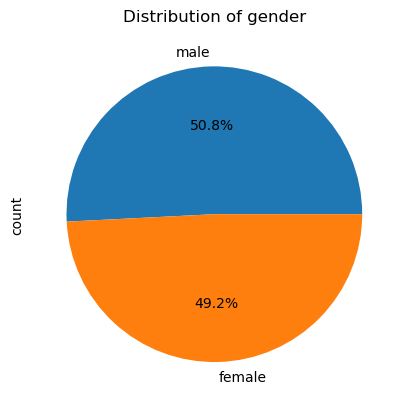

In [18]:
Gender = 'gender'
df[Gender].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title(f'Distribution of {Gender}')
plt.show()

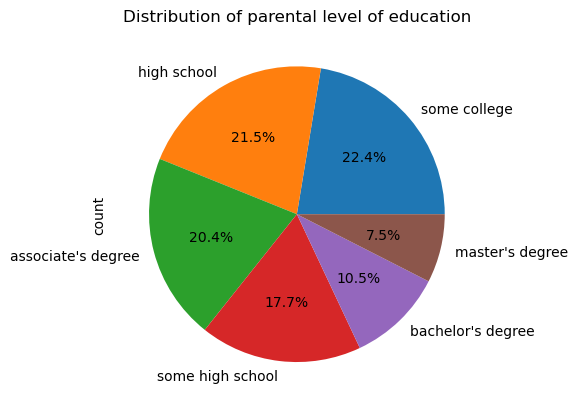

In [22]:
parent_level_education = 'parental level of education'
df[parent_level_education].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title(f'Distribution of {parent_level_education}')
plt.show()

In [ ]:
parent_level_education = 'parental level of education'
df[parent_level_education].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title(f'Distribution of {parent_level_education}')
plt.show()

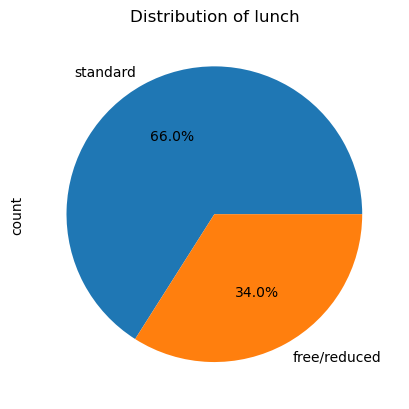

In [23]:
lunch = 'lunch'
df[lunch].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title(f'Distribution of {lunch}')
plt.show()

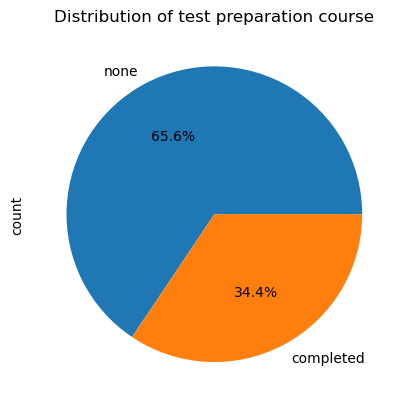

In [25]:
test_preparation_course = 'test preparation course'
df[test_preparation_course].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title(f'Distribution of {test_preparation_course}')
plt.show()

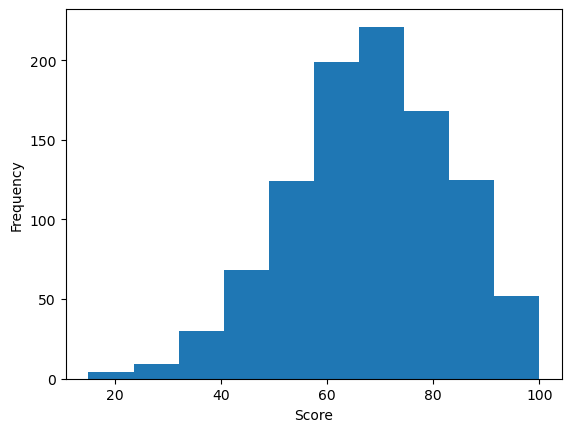

In [34]:
math_score = 'math score'
df[math_score].plot(kind='hist')
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [36]:
X = df.drop(columns = ["math score"])

In [38]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group D,some college,standard,completed,70,78
1,male,group D,associate's degree,standard,none,93,87
2,female,group D,some college,free/reduced,none,76,77
3,male,group B,some college,free/reduced,none,70,63
4,female,group D,associate's degree,standard,none,85,86


In [39]:
#creating pass or fail category
df['math_pass'] = (df['math score'] >= 70).astype(int)

In [40]:
y = df["math_pass"]

In [44]:
X = pd.get_dummies(X, drop_first=True) #encode categorical features

In [42]:
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [45]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average = 'macro')
recall = recall_score(y_test, y_pred, average= 'macro')

In [47]:
print(accuracy)
print(precision)
print(recall)

0.855
0.8541666666666667
0.8553411717415336


In [51]:
 joblib.dump(model, "math_score_prediction_model.pkl") # save model

['math_score_prediction_model.pkl']

In [60]:
joblib.dump(X.columns, "model_columns.pkl")

['model_columns.pkl']

In [63]:
loaded_model = joblib.load("math_score_prediction_model.pkl")

,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,70,78,False,False,False,True,False,False,False,False,True,False,True,False
1,93,87,True,False,False,True,False,False,False,False,False,False,True,True
2,76,77,False,False,False,True,False,False,False,False,True,False,False,True
3,70,63,True,True,False,False,False,False,False,False,True,False,False,True
4,85,86,False,False,False,True,False,False,False,False,False,False,True,True
